In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
from zipfile import ZipFile
from collections import Counter
from pathlib import PurePosixPath
import subprocess
import sys
import json

from collections import defaultdict
from io import BytesIO

from IPython.display import display
from PIL import Image, ImageDraw

In [ ]:
DRIVE_ROOT = Path('/content/drive/MyDrive/WasteScope')
PROJECT_ROOT = DRIVE_ROOT / 'wastescope-urban-intelligence'
ARCHIVE_DIR = DRIVE_ROOT / 'raw_archives'

ARCHIVES = [ARCHIVE_DIR / 'detection_task.zip', ARCHIVE_DIR / 'tracking_task.zip', ARCHIVE_DIR / 'segmentation_task.zip']

In [4]:
ARCHIVES = [ARCHIVE_DIR / 'detection_task.zip', ARCHIVE_DIR / 'tracking_task.zip', ARCHIVE_DIR / 'segmentation_task.zip']
command = [sys.executable, str(PROJECT_ROOT / 'scripts/audit_archives.py')]

for archive in ARCHIVES:
    command += ['--archive', str(archive)]

command += ['--output-dir', str(PROJECT_ROOT / 'reports/private')]
subprocess.run(command, check=True)

CompletedProcess(args=['/usr/bin/python3', '/content/drive/MyDrive/WasteScope/wastescope-urban-intelligence/scripts/audit_archives.py', '--archive', '/content/drive/MyDrive/WasteScope/raw_archives/detection_task.zip', '--archive', '/content/drive/MyDrive/WasteScope/raw_archives/tracking_task.zip', '--archive', '/content/drive/MyDrive/WasteScope/raw_archives/segmentation_task.zip', '--output-dir', '/content/drive/MyDrive/WasteScope/wastescope-urban-intelligence/reports/private'], returncode=0)

In [5]:
result = subprocess.run(command, capture_output=True, text=True)

print(result.stdout)
if result.stderr:
    print(result.stderr)

result.check_returncode()

detection_task.zip: 72957 files, 86.359 GiB ZIP, 86.464 GiB expanded
Top-level: [('Detection Task', 72957)]
Extensions: [('.txt', 36478), ('.png', 36478), ('.md', 1)]
Path checks: 0 suspicious, 0 duplicate, 0 encrypted
tracking_task.zip: 20044 files, 20.521 GiB ZIP, 20.577 GiB expanded
Top-level: [('Tracking Task', 20044)]
Extensions: [('.txt', 10022), ('.png', 10022)]
Path checks: 0 suspicious, 0 duplicate, 0 encrypted
segmentation_task.zip: 7231 files, 14.348 GiB ZIP, 14.397 GiB expanded
Top-level: [('Segmentation Task', 7231)]
Extensions: [('.png', 7230), ('.json', 1)]
Path checks: 0 suspicious, 0 duplicate, 0 encrypted
Private inventory saved: /content/drive/MyDrive/WasteScope/wastescope-urban-intelligence/reports/private/detection_task_audit.json
Private inventory saved: /content/drive/MyDrive/WasteScope/wastescope-urban-intelligence/reports/private/tracking_task_audit.json
Private inventory saved: /content/drive/MyDrive/WasteScope/wastescope-urban-intelligence/reports/private/seg

In [6]:
detection_zip = ARCHIVE_DIR / "detection_task.zip"
tracking_zip = ARCHIVE_DIR / "tracking_task.zip"
segmentation_zip = ARCHIVE_DIR / "segmentation_task.zip"

for path in [detection_zip, tracking_zip, segmentation_zip]:
    assert path.is_file, f"Missing archive: {path}"
    print(f"{path.name}: {path.stat().st_size / 1024**3:.3f} GiB")

detection_task.zip: 86.359 GiB
tracking_task.zip: 20.521 GiB
segmentation_task.zip: 14.348 GiB


In [7]:
with ZipFile(detection_zip) as zf:
    readmes = [
        item for item in zf.infolist()
        if item.filename.lower().endswith(".md")
    ]
    
    for item in readmes:
        print(f"\n===== {item.filename} =====")
        with zf.open(item) as file:
            print(file.read(20_000).decode("utf-8", errors="replace"))


===== Detection Task/README.md =====
# Informations about StreetView-Waste Dataset

## Classes:
    0: container_yellow
    1: container_green
    2: container_default
    3: container_blue
    4: container_ash
    5: container_oil
    6: container_battery
    7: container_biodegradable
  
## Image Index Ranges:

	- Images 0–124 and 156–195: Container images
	- Images 125–155 and 196–215: Background images

## Image Naming Convention:

All images follow this standard naming convention: numvid_cam_overflow_label.png, where:

- numvid: Video number (zero-padded)

- camdir:

	- 1 - camera facing right
	- 0 - camera facing left

- overflow:
	- 1 - overflow present
	- 0 - no overflow

- label:
	- 1 - positive
	- 0 - negative

Example: 0001_1_0_1.png, this is video 0001, camera facing right, no overflow, positive label (containing containers but not overflow).




In [8]:
def inspect_image_label_names(archive_path):
    with ZipFile(archive_path) as zf:
        files = [item for item in zf.infolist() if not item.is_dir()]

        images = Counter(
            PurePosixPath(item.filename).stem
            for item in files
            if item.filename.lower().endswith(".png")
        )
        labels = Counter(
            PurePosixPath(item.filename).stem
            for item in files
            if item.filename.lower().endswith(".txt")
        )

        print(f"\n{archive_path.name}")
        print("PNG:", sum(images.values()))
        print("TXT:", sum(labels.values()))
        print("PNG without matching TXT:", sum((images - labels).values()))
        print("TXT without matching PNG:", sum((labels - images).values()))
        print("Repeated PNG stems:", sum(count > 1 for count in images.values()))
        print("Repeated TXT stems:", sum(count > 1 for count in labels.values()))

        txt_files = [
            item for item in files
            if item.filename.lower().endswith(".txt")
        ]

        indices = sorted({
            0, len(txt_files) // 3,
            2 * len(txt_files) // 3, len(txt_files) - 1,
        })

        for index in indices:
            item = txt_files[index]
            print(f"\nFile: {item.filename}")
            print(f"Size: {item.file_size} bytes")

            with zf.open(item) as file:
                preview = file.read(4096).decode(
                    "utf-8", errors="replace"
                )

            lines = preview.splitlines()[:3]
            print("\n".join(lines) if lines else "<empty file>")


inspect_image_label_names(detection_zip)
inspect_image_label_names(tracking_zip)


detection_task.zip
PNG: 36478
TXT: 36478
PNG without matching TXT: 0
TXT without matching PNG: 0
Repeated PNG stems: 0
Repeated TXT stems: 0

File: Detection Task/labels/0146_1_0_0_0056.txt
Size: 0 bytes
<empty file>

File: Detection Task/labels/0205_0_0_0_0051.txt
Size: 0 bytes
<empty file>

File: Detection Task/labels/0138_1_0_0_0298.txt
Size: 0 bytes
<empty file>

File: Detection Task/labels/0041_0_1_1_0092.txt
Size: 151 bytes
4 0.128914 0.521491 0.021234 0.196000
1 0.107708 0.520106 0.019490 0.170361
2 0.185044 0.535273 0.090016 0.246972

tracking_task.zip
PNG: 10022
TXT: 10022
PNG without matching TXT: 0
TXT without matching PNG: 0
Repeated PNG stems: 0
Repeated TXT stems: 0

File: Tracking Task/labels/0030_1_0_1_0128.txt
Size: 220 bytes
2 0.504807 0.656583 0.191844 0.324907 1.0 2
3 0.884505 0.526343 0.016719 0.115833 1.0 3
1 0.851065 0.525611 0.050161 0.132704 1.0 4

File: Tracking Task/labels/0021_1_0_1_0033.txt
Size: 44 bytes
2 0.908768 0.544181 0.022286 0.057435 1.0 4

File: 

In [9]:
with ZipFile(segmentation_zip) as zf:
    json_files = [
        item for item in zf.infolist()
        if item.filename.lower().endswith(".json")
    ]
    print("\nSegmentation JSON:")
    for item in json_files:
        print(item.filename, f"{item.file_size / 1024**2:.2f} MiB")


Segmentation JSON:
Segmentation Task/labels.json 14.11 MiB


In [10]:
with ZipFile(segmentation_zip) as zf:
    json_info = next(
        item for item in zf.infolist()
        if item.filename.lower().endswith(".json")
    )
    
    with zf.open(json_info) as file:
        data = json.load(file)
    
print("Top-level type:", type(data).__name__)

Top-level type: dict


In [11]:
if isinstance(data, dict):
    print("Top-level keys:", list(data.keys()))

    for key, value in data.items():
        length = len(value) if hasattr(value, "__len__") else "N/A"
        print(f"{key}: {type(value).__name__}, length={length}")

        if isinstance(value, list) and value:
            first = value[0]
            if isinstance(first, dict):
                print("First item keys:", list(first.keys()))
            else:
                print("First item type:", type(first).__name__)

    images = data.get("images")
    annotations = data.get("annotations")
    categories = data.get("categories")

    if isinstance(images, list) and images and isinstance(images[0], dict):
        print("\nFirst image metadata:")
        for key in ("id", "file_name", "width", "height"):
            if key in images[0]:
                print(f"  {key}: {images[0][key]}")

    if isinstance(annotations, list) and annotations and isinstance(annotations[0], dict):
        print("\nFirst annotation metadata:")
        for key in ("id", "image_id", "category_id", "bbox", "area", "iscrowd"):
            if key in annotations[0]:
                print(f"  {key}: {annotations[0][key]}")

    if isinstance(categories, list):
        print("\nCategories:", categories[:10])

elif isinstance(data, list):
    print("Items:", len(data))
    if data and isinstance(data[0], dict):
        print("First item keys:", list(data[0].keys()))

Top-level keys: ['licenses', 'info', 'categories', 'images', 'annotations']
licenses: list, length=1
First item keys: ['name', 'id', 'url']
info: dict, length=6
categories: list, length=9
First item keys: ['id', 'name', 'supercategory']
images: list, length=7230
First item keys: ['id', 'width', 'height', 'file_name', 'license', 'flickr_url', 'coco_url', 'date_captured']
annotations: list, length=36754
First item keys: ['id', 'image_id', 'category_id', 'segmentation', 'area', 'bbox', 'iscrowd', 'attributes']

First image metadata:
  id: 1
  file_name: 0002_1_1_1_0000.png
  width: 1920
  height: 1080

First annotation metadata:
  id: 1
  image_id: 1
  category_id: 1
  bbox: [247.53, 478.5, 54.71, 42.57]
  area: 1266.0
  iscrowd: 0

Categories: [{'id': 1, 'name': 'Overflow', 'supercategory': ''}, {'id': 2, 'name': 'container_yellow', 'supercategory': ''}, {'id': 3, 'name': 'container_green', 'supercategory': ''}, {'id': 4, 'name': 'container_default', 'supercategory': ''}, {'id': 5, 'name

In [12]:


categories = {
    item["id"]: item["name"]
    for item in data["categories"]
}

annotations = data["annotations"]
images = data["images"]

counts = Counter(item["category_id"] for item in annotations)

print("Annotations by category:")
for category_id, name in categories.items():
    print(f"{category_id:>2}  {name:<28} {counts[category_id]}")

Annotations by category:
 1  Overflow                     5149
 2  container_yellow             5191
 3  container_green              4909
 4  container_default            12349
 5  container_blue               5448
 6  container_ash                212
 7  container_oil                983
 8  container_battery            1301
 9  container_biodegradable      1212


In [13]:
overflow_id = next(
    category_id
    for category_id, name in categories.items()
    if name.lower() == "overflow"
)

all_image_ids = {item["id"] for item in images}
overflow_image_ids = {
    item["image_id"]
    for item in annotations
    if item["category_id"] == overflow_id
}

print("\nImages with Overflow:", len(overflow_image_ids))
print("Images without Overflow:", len(all_image_ids - overflow_image_ids))
print(
    "Annotations referencing unknown images:",
    sum(item["image_id"] not in all_image_ids for item in annotations)
)


Images with Overflow: 4197
Images without Overflow: 3033
Annotations referencing unknown images: 0


In [14]:
json_names = Counter(item["file_name"] for item in images)

with ZipFile(segmentation_zip) as zf:
    zip_names = Counter(
        PurePosixPath(item.filename).name
        for item in zf.infolist()
        if item.filename.lower().endswith(".png")
    )

print("\nJSON image names without matching PNG:", sum((json_names - zip_names).values()))
print("ZIP PNG names absent from JSON:", sum((zip_names - json_names).values()))


JSON image names without matching PNG: 0
ZIP PNG names absent from JSON: 0


In [15]:
overflow_annotations = [
    item for item in annotations
    if item["category_id"] == overflow_id
]

print(
    "Overflow segmentation formats:",
    Counter(type(item.get("segmentation")).__name__ for item in overflow_annotations)
)
print(
    "Overflow annotations with empty segmentation:",
    sum(not item.get("segmentation") for item in overflow_annotations)
)

Overflow segmentation formats: Counter({'list': 5149})
Overflow annotations with empty segmentation: 0


In [17]:
annotations_per_image = Counter(
    item["image_id"] for item in annotations
)

overflow_per_image = Counter(
    item["image_id"] for item in overflow_annotations
)

negative_ids = all_image_ids - overflow_image_ids

print(
    "Images with no annotations of any category:",
    sum(annotations_per_image[image_id] == 0 for image_id in all_image_ids)
)
print(
    "Overflow-negative images with container annotations:",
    sum(annotations_per_image[image_id] > 0 for image_id in negative_ids)
)
print(
    "Most Overflow instances in one image:",
    max(overflow_per_image.values())
)

Images with no annotations of any category: 168
Overflow-negative images with container annotations: 2865
Most Overflow instances in one image: 3


In [18]:
sample = overflow_annotations[0]["segmentation"]
print("First Overflow segmentation:")
print("Outer type:", type(sample).__name__)
print("Number of parts:", len(sample))

if sample:
    print("First part type:", type(sample[0]).__name__)
    if isinstance(sample[0], list):
        print("Coordinates in first part:", len(sample[0]))
        print("First six numbers:", sample[0][:6])

First Overflow segmentation:
Outer type: list
Number of parts: 1
First part type: list
Coordinates in first part: 26
First six numbers: [302.24, 495.66, 301.32, 484.22, 291.02, 478.5]


In [ ]:
image_by_id = {item["id"]: item for item in images}
annotations_by_image = defaultdict(list)

for item in annotations:
    annotations_by_image[item["image_id"]].append(item)


one_overflow = next(
    image_id for image_id, count in overflow_per_image.items()
    if count == 1
)
three_overflows = next(
    image_id for image_id, count in overflow_per_image.items()
    if count == 3
)

container_only = next(
    image_id for image_id in negative_ids
    if annotations_by_image[image_id]
)
no_annotations = next(
    image_id for image_id in negative_ids
    if not annotations_by_image[image_id]
)

One Overflow | 0002_1_1_1_0000.png | 1 annotations


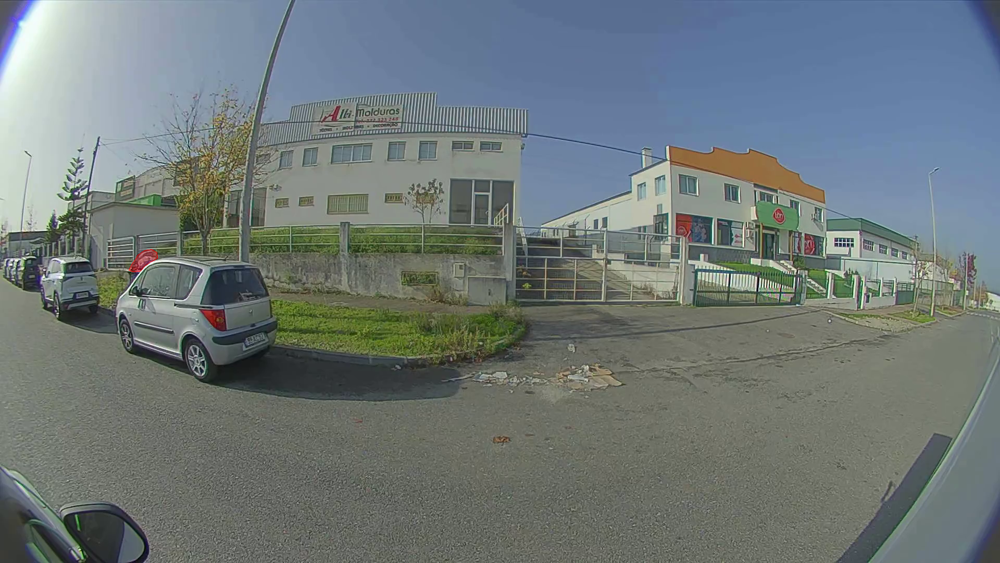

Three Overflows | 0044_1_1_1_0029.png | 7 annotations


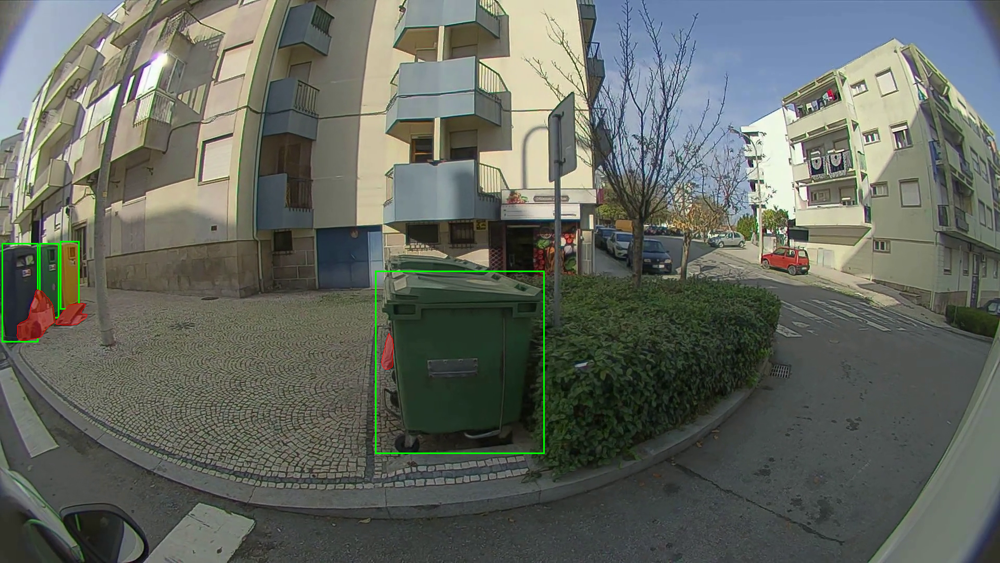

Containers, no Overflow | 0008_1_1_1_0001.png | 1 annotations


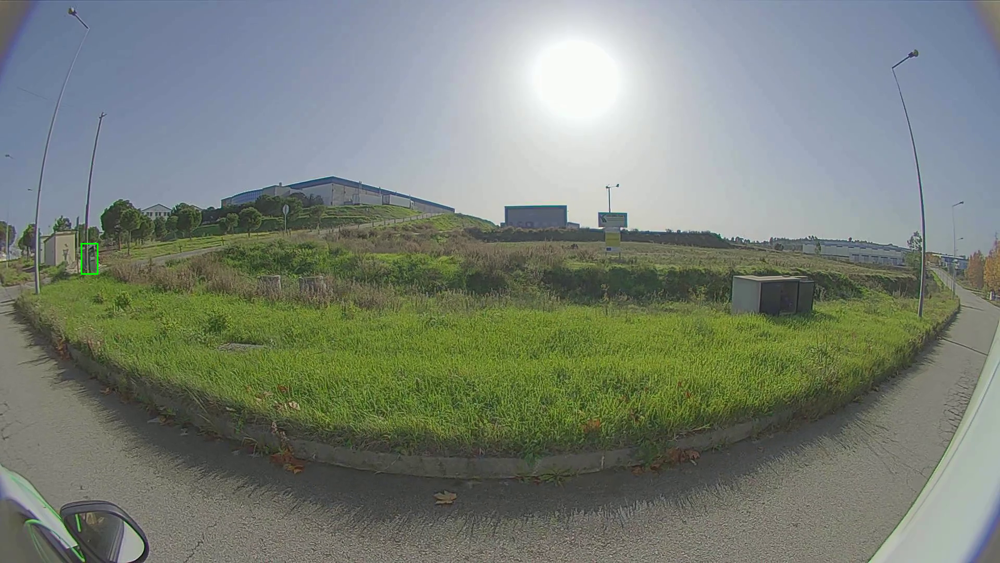

No annotations | 0008_1_1_1_0000.png | 0 annotations


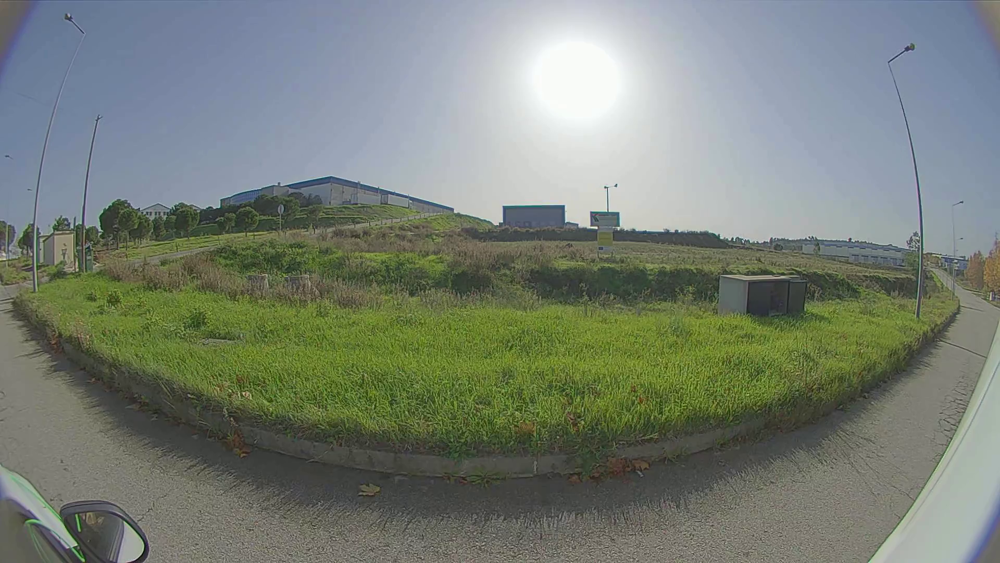

In [20]:
examples = {
    "One Overflow": one_overflow,
    "Three Overflows": three_overflows,
    "Containers, no Overflow": container_only,
    "No annotations": no_annotations,
}

with ZipFile(segmentation_zip) as zf:
    png_members = {
        PurePosixPath(item.filename).name: item
        for item in zf.infolist()
        if item.filename.lower().endswith(".png")
    }
    
    for title, image_id in examples.items():
        image_info = image_by_id[image_id]
        filename = image_info["file_name"]

        image = Image.open(
            BytesIO(zf.read(png_members[filename]))
        ).convert("RGBA")

        overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
        draw = ImageDraw.Draw(overlay)
        
        for ann in annotations_by_image[image_id]:
            if ann["category_id"] == overflow_id:
                for polygon in ann["segmentation"]:
                    if len(polygon) < 6 or len(polygon) % 2:
                        raise ValueError(f"Invalid polygon: annotation {ann['id']}")
                    
                    points = list(zip(polygon[0::2], polygon[1::2]))
                    draw.polygon(
                        points,
                        fill=(255, 0, 0, 85),
                        outline=(255, 0, 0, 255)
                    )
            
            else:
                x, y, width, height = ann["bbox"]
                draw.rectangle(
                    (x, y, x + width, y + height),
                    outline=(0, 255, 0, 255),
                    width=3
                )
        
        preview = Image.alpha_composite(image, overlay).convert("RGB")
        preview.thumbnail((1000, 1000))

        print(
            f"{title} | {filename} | "
            f"{len(annotations_by_image[image_id])} annotations"
        )
        display(preview)
                